# Modelo actual de clones de codigo en Python

En este notebook dejamos la version final limpia del modelo.

- Capa 1 lexica (TF-IDF, similitudes y Baker).
- Capa 2 AST mejorada (estructura real y complejidad).
- Clasificador final Random Forest.

El objetivo principal es mejorar deteccion de `type_III` y `type_IV`.


## 1) Configuracion e imports
En esta etapa dejamos listas las librerias que vamos a usar en todo el flujo.
Tambien dejamos una semilla fija para que los resultados se puedan repetir.
Esta ya es la base final del modelo actual.


In [1]:
# Librerias base para carga, preprocesamiento, features y modelado
from pathlib import Path
from typing import Any, Iterable
from difflib import SequenceMatcher
import random
import re
import keyword
import ast
import importlib.util
import io
import tokenize

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display




In [2]:
# Configuración global para reproducibilidad
SEED = 42

import warnings
warnings.filterwarnings('ignore', category=SyntaxWarning)

random.seed(SEED)
np.random.seed(SEED)

print('SEED:', SEED)


SEED: 42


## 2) Dataset y reconstruccion de pares
Aqui leemos las carpetas T1, T2, T3 y T4 del dataset.
Cada archivo trae dos snippets y los convertimos a filas de trabajo.
Con esto formamos la tabla principal que alimenta el modelo.


In [3]:
# Rutas fijas del proyecto (supuesto: estructura correcta siempre disponible)
RUTA_BASE = Path.cwd()
RUTA_DATASET = RUTA_BASE / 'DataBaseProject' if (RUTA_BASE / 'DataBaseProject').exists() else RUTA_BASE
RUTA_PARES = RUTA_DATASET / 'pares_clones'

PATRON_SEPARADOR_SNIPPETS = re.compile(r'\n\s*\n\s*\n+')
PATRON_ESPACIOS = re.compile(r'[ \t]+')
PATRON_SALTOS = re.compile(r'\n{3,}')

TIPOS_CLON = ['T1', 'T2', 'T3', 'T4']
TIPO_A_CLASE = {
    'T1': 'type_I',
    'T2': 'type_II',
    'T3': 'type_III',
    'T4': 'type_IV',
}
TIPO_A_GRUPO = {
    'T1': 'pares_t1',
    'T2': 'pares_t2',
    'T3': 'pares_t3',
    'T4': 'pares_t4',
}

COLUMNAS_PARES = [
    'is_clone', 'clone_type', 'source_group', 'filename', 'file_path',
    'problem_id', 'snippet_index_a', 'snippet_index_b',
    'resolved_path', 'snippet_count', 'code_a', 'code_b'
]

def separar_snippets(texto_archivo: str) -> list[str]:
    texto = texto_archivo.replace('\r\n', '\n').replace('\r', '\n').strip()
    return [p.strip() for p in PATRON_SEPARADOR_SNIPPETS.split(texto) if p.strip()]

def cargar_pares_desde_carpetas(ruta_pares: Path) -> pd.DataFrame:
    filas = []
    for tipo in TIPOS_CLON:
        carpeta_tipo = ruta_pares / tipo
        for archivo in sorted(carpeta_tipo.glob('*.py')):
            texto = archivo.read_text(encoding='utf-8', errors='replace')
            snippets = separar_snippets(texto)
            problem_id = int(archivo.stem.split('_')[1])
            filas.append({
                'is_clone': 1,
                'clone_type': TIPO_A_CLASE[tipo],
                'source_group': TIPO_A_GRUPO[tipo],
                'filename': archivo.name,
                'file_path': str(archivo.relative_to(RUTA_DATASET)).replace('/', '\\'),
                'problem_id': problem_id,
                'snippet_index_a': 0,
                'snippet_index_b': 1,
                'resolved_path': str(archivo),
                'snippet_count': len(snippets),
                'code_a': snippets[0],
                'code_b': snippets[1],
            })
    return pd.DataFrame(filas, columns=COLUMNAS_PARES)


In [4]:
# Carga de pares del dataset
datos_reconstruidos = cargar_pares_desde_carpetas(RUTA_PARES)

resumen_reconstruccion = {
    'reconstructed_rows': int(len(datos_reconstruidos)),
    'num_problem_id': int(datos_reconstruidos['problem_id'].nunique()),
    'tipos': datos_reconstruidos['clone_type'].value_counts().to_dict(),
}

print('Filas reconstruidas:', len(datos_reconstruidos))
print('Resumen reconstruccion:', resumen_reconstruccion)


Filas reconstruidas: 8400
Resumen reconstruccion: {'reconstructed_rows': 8400, 'num_problem_id': 2100, 'tipos': {'type_I': 2100, 'type_II': 2100, 'type_III': 2100, 'type_IV': 2100}}


## 3) Preprocesamiento
En esta etapa limpiamos texto de codigo y armamos tokens.
El objetivo es que todos los pares se comparen con el mismo formato.
Esto facilita las metricas de similitud de la capa lexica.


In [5]:
def quitar_comentarios(codigo: str) -> str:
    # Esta funcion limpia comentarios para comparar el codigo por su logica y no por texto extra.
    lineas = codigo.expandtabs(4).splitlines()
    limpias = []
    for ln in lineas:
        parte = ln.split('#', 1)[0]
        limpias.append(parte)
    return '\n'.join(limpias)


def normalizar_espacios(codigo: str) -> str:
    # Esta funcion estandariza espacios y saltos para que todos los snippets tengan formato comparable.
    lineas = [PATRON_ESPACIOS.sub(' ', linea).rstrip() for linea in codigo.splitlines()]
    normalizado = '\n'.join(lineas).strip()
    return PATRON_SALTOS.sub('\n\n', normalizado)


def preprocesar_codigo(codigo: str) -> str:
    # Esta funcion aplica el flujo de limpieza completo en un solo paso.
    return normalizar_espacios(quitar_comentarios(codigo))


def tokenizar_python(codigo: str) -> list[str]:
    # Esta funcion convierte codigo en tokens basicos para medir similitud lexica.
    patron = r'[A-Za-z_]\w*|\d+|==|!=|<=|>=|[][(){}.,:;+*/%=<>-]'
    return re.findall(patron, codigo)


def firma_tipo_i_canonica(codigo: str) -> str:
    # Firma estricta para Type I: ignora comentarios y formato, conserva el codigo real.
    codigo_ok = codigo.replace('\\r\\n', '\n').replace('\\n', '\n').replace('\\r', '\n')
    codigo_ok = codigo_ok.replace('\r\n', '\n').replace('\n', '\n').replace('\r', '\n')
    codigo_ok = codigo_ok.expandtabs(4)

    tokens = []
    ignorar = {
        tokenize.NL,
        tokenize.NEWLINE,
        tokenize.INDENT,
        tokenize.DEDENT,
        tokenize.COMMENT,
        tokenize.ENCODING,
        tokenize.ENDMARKER,
    }

    try:
        flujo = tokenize.generate_tokens(io.StringIO(codigo_ok).readline)
        for tok in flujo:
            if tok.type in ignorar:
                continue
            tokens.append(tok.string)
    except Exception:
        # Fallback para snippets incompletos: tokenizacion regex sobre codigo preprocesado.
        tokens = tokenizar_python(preprocesar_codigo(codigo_ok))

    return ' '.join(tokens)


def preparar_campos_par(df: pd.DataFrame) -> pd.DataFrame:
    # Esta funcion crea todas las columnas derivadas que usara el modelo despues.
    out = df.copy()
    out['code_a_clean'] = [preprocesar_codigo(x) for x in out['code_a'].astype(str)]
    out['code_b_clean'] = [preprocesar_codigo(x) for x in out['code_b'].astype(str)]
    out['tokens_a'] = [tokenizar_python(x) for x in out['code_a_clean']]
    out['tokens_b'] = [tokenizar_python(x) for x in out['code_b_clean']]
    out['token_text_a'] = [' '.join(t) for t in out['tokens_a']]
    out['token_text_b'] = [' '.join(t) for t in out['tokens_b']]

    # Firmas canonicas para la etapa deterministica de Type I.
    out['type1_signature_a'] = [firma_tipo_i_canonica(x) for x in out['code_a'].astype(str)]
    out['type1_signature_b'] = [firma_tipo_i_canonica(x) for x in out['code_b'].astype(str)]
    return out


datos_preparados = preparar_campos_par(datos_reconstruidos)
print('Filas listas para modelado:', len(datos_preparados))



Filas listas para modelado: 8400


## 4) Capa 1 lexica
Aqui calculamos similitud por tokens y por TF-IDF.
Tambien agregamos Baker simplificado para capturar bloques similares.
Esta capa captura parecido textual y cambios de nombres/literales.


In [6]:
def similitud_jaccard(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    set_a, set_b = set(tokens_a), set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    union = set_a | set_b
    if not union:
        return 0.0
    return float(len(set_a & set_b) / len(union))


def similitud_dice(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    set_a, set_b = set(tokens_a), set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    denom = len(set_a) + len(set_b)
    if denom == 0:
        return 0.0
    return float(2.0 * len(set_a & set_b) / denom)


def ratio_overlap(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    set_a, set_b = set(tokens_a), set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    min_size = min(len(set_a), len(set_b))
    if min_size == 0:
        return 0.0
    return float(len(set_a & set_b) / min_size)


def ajustar_tfidf(df_train: pd.DataFrame) -> TfidfVectorizer:
    corpus = pd.concat([df_train['token_text_a'], df_train['token_text_b']], axis=0)
    vector = TfidfVectorizer(
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        ngram_range=(1, 2),
        min_df=1,
    )
    vector.fit(corpus)
    return vector


def coseno_fila_a_fila(mat_a: sparse.spmatrix, mat_b: sparse.spmatrix) -> np.ndarray:
    producto = np.asarray(mat_a.multiply(mat_b).sum(axis=1)).ravel()
    norma_a = np.sqrt(np.asarray(mat_a.multiply(mat_a).sum(axis=1)).ravel())
    norma_b = np.sqrt(np.asarray(mat_b.multiply(mat_b).sum(axis=1)).ravel())
    denom = norma_a * norma_b
    denom[denom == 0.0] = 1e-12
    return producto / denom


def construir_features_lexicas_base(df: pd.DataFrame, vector: TfidfVectorizer) -> pd.DataFrame:
    mat_a = vector.transform(df['token_text_a'])
    mat_b = vector.transform(df['token_text_b'])

    chars_a = df['code_a_clean'].str.len().astype(float)
    chars_b = df['code_b_clean'].str.len().astype(float)
    toks_a = df['tokens_a'].apply(len).astype(float)
    toks_b = df['tokens_b'].apply(len).astype(float)

    return pd.DataFrame({
        'lex_cosine_tfidf': coseno_fila_a_fila(mat_a, mat_b),
        'lex_jaccard_tokens': [similitud_jaccard(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])],
        'lex_dice_tokens': [similitud_dice(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])],
        'lex_overlap_tokens': [ratio_overlap(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])],
        'len_chars_a': chars_a,
        'len_chars_b': chars_b,
        'len_chars_diff_abs': (chars_a - chars_b).abs(),
        'len_tokens_a': toks_a,
        'len_tokens_b': toks_b,
        'len_tokens_diff_abs': (toks_a - toks_b).abs(),
    }, index=df.index)


def baker_tokenizar_generalizar(codigo: str) -> list[str]:
    # Baker generaliza identificadores, numeros y strings.
    codigo_ok = codigo.replace('\\r\\n', '\n').replace('\\n', '\n').replace('\\r', '\n')
    codigo_ok = codigo_ok.replace('\r\n', '\n').replace('\n', '\n').replace('\r', '\n').expandtabs(4)

    out = []
    ignorar = {
        tokenize.NL,
        tokenize.NEWLINE,
        tokenize.INDENT,
        tokenize.DEDENT,
        tokenize.COMMENT,
        tokenize.ENCODING,
        tokenize.ENDMARKER,
    }

    try:
        flujo = tokenize.generate_tokens(io.StringIO(codigo_ok).readline)
        for tok in flujo:
            if tok.type in ignorar:
                continue
            if tok.type == tokenize.NAME:
                out.append(tok.string if keyword.iskeyword(tok.string) else 'ID')
            elif tok.type == tokenize.NUMBER:
                out.append('NUM')
            elif tok.type == tokenize.STRING:
                out.append('STR')
            elif tok.type == tokenize.OP:
                out.append(tok.string)
            else:
                out.append(tok.string)
    except Exception:
        # Fallback simple por regex para snippets muy sucios.
        tokens = re.findall(r'[A-Za-z_]\w*|\d+|==|!=|<=|>=|[\[\](){}.,:;+*/%=<>-]', codigo_ok)
        for t in tokens:
            if re.fullmatch(r'[A-Za-z_]\w*', t):
                out.append(t if keyword.iskeyword(t) else 'ID')
            elif re.fullmatch(r'\d+', t):
                out.append('NUM')
            else:
                out.append(t)
    return out


def _levenshtein_tokens(seq_a: list[str], seq_b: list[str]) -> int:
    n, m = len(seq_a), len(seq_b)
    if n == 0:
        return m
    if m == 0:
        return n

    prev = list(range(m + 1))
    for i in range(1, n + 1):
        curr = [i] + [0] * m
        ai = seq_a[i - 1]
        for j in range(1, m + 1):
            cost = 0 if ai == seq_b[j - 1] else 1
            curr[j] = min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + cost)
        prev = curr
    return int(prev[m])


def baker_features_par(codigo_a: str, codigo_b: str, min_match_len: int = 3) -> dict[str, float]:
    ta = baker_tokenizar_generalizar(codigo_a)
    tb = baker_tokenizar_generalizar(codigo_b)

    if len(ta) == 0 and len(tb) == 0:
        return {
            'baker_match_total_ratio': 1.0,
            'baker_match_max_ratio': 1.0,
            'baker_num_blocks': 0.0,
            'baker_sequence_ratio': 1.0,
            'baker_edit_distance_norm': 0.0,
            'baker_token_jaccard': 1.0,
            'baker_common_token_coverage': 1.0,
            'baker_len_diff_rel': 0.0,
        }

    if len(ta) == 0 or len(tb) == 0:
        return {
            'baker_match_total_ratio': 0.0,
            'baker_match_max_ratio': 0.0,
            'baker_num_blocks': 0.0,
            'baker_sequence_ratio': 0.0,
            'baker_edit_distance_norm': 1.0,
            'baker_token_jaccard': 0.0,
            'baker_common_token_coverage': 0.0,
            'baker_len_diff_rel': 1.0,
        }

    matcher = SequenceMatcher(a=ta, b=tb, autojunk=False)
    blocks = [b for b in matcher.get_matching_blocks() if b.size >= min_match_len]
    total_match = float(sum(b.size for b in blocks))
    max_match = float(max([b.size for b in blocks], default=0.0))

    base_min = float(min(len(ta), len(tb)))
    base_max = float(max(len(ta), len(tb)))

    set_a, set_b = set(ta), set(tb)
    union = set_a | set_b
    inter = set_a & set_b

    edit_dist = float(_levenshtein_tokens(ta, tb))

    return {
        'baker_match_total_ratio': total_match / base_min,
        'baker_match_max_ratio': max_match / base_min,
        'baker_num_blocks': float(len(blocks)),
        'baker_sequence_ratio': float(matcher.ratio()),
        'baker_edit_distance_norm': edit_dist / max(1.0, base_max),
        'baker_token_jaccard': float(len(inter) / len(union)) if len(union) > 0 else 0.0,
        'baker_common_token_coverage': float(len(inter) / max(1, min(len(set_a), len(set_b)))),
        'baker_len_diff_rel': abs(len(ta) - len(tb)) / max(1.0, base_max),
    }


def construir_features_baker(df: pd.DataFrame, min_match_len: int = 3) -> pd.DataFrame:
    rows = [
        baker_features_par(a, b, min_match_len=min_match_len)
        for a, b in zip(df['code_a_clean'], df['code_b_clean'])
    ]
    return pd.DataFrame(rows, index=df.index)


def construir_features_modelo_capa1(df: pd.DataFrame, vector: TfidfVectorizer, min_match_len: int = 3) -> pd.DataFrame:
    fx_lex = construir_features_lexicas_base(df, vector)
    fx_baker = construir_features_baker(df, min_match_len=min_match_len)
    return pd.concat([fx_lex, fx_baker], axis=1)

# -----------------------------------------------------------------
# Baker mejorado para reforzar type_III y type_IV
# -----------------------------------------------------------------
def _baker_ngram_set(tokens: list[str], n: int) -> set[tuple[str, ...]]:
    if len(tokens) < n:
        return set()
    return {tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)}


def _jaccard_set(a: set, b: set) -> float:
    if not a and not b:
        return 1.0
    u = a | b
    return float(len(a & b) / len(u)) if u else 0.0


def _lcs_len_tokens(seq_a: list[str], seq_b: list[str]) -> int:
    n, m = len(seq_a), len(seq_b)
    if n == 0 or m == 0:
        return 0
    prev = [0] * (m + 1)
    curr = [0] * (m + 1)
    for i in range(1, n + 1):
        ai = seq_a[i - 1]
        for j in range(1, m + 1):
            if ai == seq_b[j - 1]:
                curr[j] = prev[j - 1] + 1
            else:
                curr[j] = prev[j] if prev[j] >= curr[j - 1] else curr[j - 1]
        prev, curr = curr, [0] * (m + 1)
    return int(prev[m])


def baker_features_par(codigo_a: str, codigo_b: str, min_match_len: int = 3) -> dict[str, float]:
    ta = baker_tokenizar_generalizar(codigo_a)
    tb = baker_tokenizar_generalizar(codigo_b)

    base_keys = [
        'baker_match_total_ratio',
        'baker_match_max_ratio',
        'baker_num_blocks',
        'baker_sequence_ratio',
        'baker_edit_distance_norm',
        'baker_token_jaccard',
        'baker_common_token_coverage',
        'baker_len_diff_rel',
        'baker_lcs_ratio',
        'baker_bigram_jaccard',
        'baker_trigram_jaccard',
        'baker_keyword_overlap',
        'baker_operator_overlap',
        'baker_literal_density_diff',
        'baker_identifier_density_diff',
    ]

    if len(ta) == 0 and len(tb) == 0:
        vals = {
            'baker_match_total_ratio': 1.0,
            'baker_match_max_ratio': 1.0,
            'baker_num_blocks': 0.0,
            'baker_sequence_ratio': 1.0,
            'baker_edit_distance_norm': 0.0,
            'baker_token_jaccard': 1.0,
            'baker_common_token_coverage': 1.0,
            'baker_len_diff_rel': 0.0,
            'baker_lcs_ratio': 1.0,
            'baker_bigram_jaccard': 1.0,
            'baker_trigram_jaccard': 1.0,
            'baker_keyword_overlap': 1.0,
            'baker_operator_overlap': 1.0,
            'baker_literal_density_diff': 0.0,
            'baker_identifier_density_diff': 0.0,
        }
        return vals

    if len(ta) == 0 or len(tb) == 0:
        vals = {
            'baker_match_total_ratio': 0.0,
            'baker_match_max_ratio': 0.0,
            'baker_num_blocks': 0.0,
            'baker_sequence_ratio': 0.0,
            'baker_edit_distance_norm': 1.0,
            'baker_token_jaccard': 0.0,
            'baker_common_token_coverage': 0.0,
            'baker_len_diff_rel': 1.0,
            'baker_lcs_ratio': 0.0,
            'baker_bigram_jaccard': 0.0,
            'baker_trigram_jaccard': 0.0,
            'baker_keyword_overlap': 0.0,
            'baker_operator_overlap': 0.0,
            'baker_literal_density_diff': 1.0,
            'baker_identifier_density_diff': 1.0,
        }
        return vals

    matcher = SequenceMatcher(a=ta, b=tb, autojunk=False)
    blocks = [b for b in matcher.get_matching_blocks() if b.size >= min_match_len]
    total_match = float(sum(b.size for b in blocks))
    max_match = float(max([b.size for b in blocks], default=0.0))

    base_min = float(min(len(ta), len(tb)))
    base_max = float(max(len(ta), len(tb)))

    set_a, set_b = set(ta), set(tb)
    union = set_a | set_b
    inter = set_a & set_b

    edit_dist = float(_levenshtein_tokens(ta, tb))
    lcs_ratio = float(_lcs_len_tokens(ta, tb) / max(1.0, base_min))

    bigram_j = _jaccard_set(_baker_ngram_set(ta, 2), _baker_ngram_set(tb, 2))
    trigram_j = _jaccard_set(_baker_ngram_set(ta, 3), _baker_ngram_set(tb, 3))

    kw = set(keyword.kwlist)
    kw_a = {t for t in ta if t in kw}
    kw_b = {t for t in tb if t in kw}
    kw_overlap = _jaccard_set(kw_a, kw_b)

    op_pool = {'+', '-', '*', '/', '//', '%', '**', '=', '==', '!=', '<', '>', '<=', '>=',
               '+=', '-=', '*=', '/=', '%=', 'and', 'or', 'not', 'in', 'is', '(', ')', '[', ']', '{', '}', '.', ',', ':'}
    op_a = {t for t in ta if t in op_pool}
    op_b = {t for t in tb if t in op_pool}
    op_overlap = _jaccard_set(op_a, op_b)

    dens_lit_a = float((ta.count('NUM') + ta.count('STR')) / max(1, len(ta)))
    dens_lit_b = float((tb.count('NUM') + tb.count('STR')) / max(1, len(tb)))
    dens_id_a = float(ta.count('ID') / max(1, len(ta)))
    dens_id_b = float(tb.count('ID') / max(1, len(tb)))

    vals = {
        'baker_match_total_ratio': total_match / base_min,
        'baker_match_max_ratio': max_match / base_min,
        'baker_num_blocks': float(len(blocks)),
        'baker_sequence_ratio': float(matcher.ratio()),
        'baker_edit_distance_norm': edit_dist / max(1.0, base_max),
        'baker_token_jaccard': float(len(inter) / len(union)) if len(union) > 0 else 0.0,
        'baker_common_token_coverage': float(len(inter) / max(1, min(len(set_a), len(set_b)))),
        'baker_len_diff_rel': abs(len(ta) - len(tb)) / max(1.0, base_max),
        'baker_lcs_ratio': lcs_ratio,
        'baker_bigram_jaccard': bigram_j,
        'baker_trigram_jaccard': trigram_j,
        'baker_keyword_overlap': kw_overlap,
        'baker_operator_overlap': op_overlap,
        'baker_literal_density_diff': abs(dens_lit_a - dens_lit_b),
        'baker_identifier_density_diff': abs(dens_id_a - dens_id_b),
    }

    return {k: float(vals[k]) for k in base_keys}


def construir_features_baker(df: pd.DataFrame, min_match_len: int = 3) -> pd.DataFrame:
    rows = [
        baker_features_par(a, b, min_match_len=min_match_len)
        for a, b in zip(df['code_a_clean'], df['code_b_clean'])
    ]
    return pd.DataFrame(rows, index=df.index)



## 5) Capa 2 AST y capa FA-AST de flujo
En esta etapa cada bloque tiene comentarios didacticos para que se entienda el objetivo de la logica.
Se explica con lenguaje sencillo por que se usa cada condicion y cada ciclo importante.


In [7]:
AST_METRIC_KEYS = [
    'ast_total_nodes',
    'ast_depth',
    'ast_num_functions',
    'ast_num_loops',
    'ast_num_ifs',
    'ast_num_calls',
    'ast_num_imports',
    'ast_num_returns',
    'ast_num_assigns',
    'ast_num_comprehensions',
    'ast_num_try',
    'ast_num_branches',
    'ast_cyclomatic',
    'ast_unique_identifiers',
]

_RAPIDFUZZ_AVAILABLE = importlib.util.find_spec('rapidfuzz') is not None
# Si esta condicion se cumple, usamos este camino de logica.
if _RAPIDFUZZ_AVAILABLE:
    from rapidfuzz.distance import Levenshtein as _RF_LEV


def _iter_nodes(root: ast.AST):
    return list(ast.walk(root))


def _max_depth(root: ast.AST) -> float:
    max_d = 0

    def rec(node: ast.AST, d: int):
        nonlocal max_d
        # Si esta condicion se cumple, usamos este camino de logica.
        if d > max_d:
            max_d = d
        # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
        for ch in ast.iter_child_nodes(node):
            rec(ch, d + 1)

    rec(root, 0)
    return float(max_d)


def _count_nodes(nodes: list[ast.AST], tipos: tuple[type, ...]) -> int:
    return sum(1 for n in nodes if isinstance(n, tipos))


def _identificadores(root: ast.AST) -> set[str]:
    ids = set()
    # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
    for n in ast.walk(root):
        # Si esta condicion se cumple, usamos este camino de logica.
        if isinstance(n, ast.Name):
            ids.add(n.id)
        # Si la condicion anterior no se cumplio, probamos esta alternativa.
        elif isinstance(n, ast.arg):
            ids.add(n.arg)
    return ids


def _type_count_map(nodes: list[ast.AST]) -> dict[str, int]:
    mapa: dict[str, int] = {}
    # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
    for n in nodes:
        k = type(n).__name__
        mapa[k] = mapa.get(k, 0) + 1
    return mapa


def _normalizar_bloques_minimos(codigo: str) -> str:
    # Convierte escapes literales y completa bloques vacios para parseo AST.
    codigo = codigo.replace('\\\\r\\\\n', '\n').replace('\\\\n', '\n').replace('\\\\r', '\n')
    codigo = codigo.replace('\\r\\n', '\n').replace('\\n', '\n').replace('\\r', '\n')
    codigo = codigo.replace('\\t', '    ').replace('\t', '    ')
    lineas = codigo.expandtabs(4).splitlines()
    out = []

    i = 0
    # Este bloque se repite mientras la condicion siga siendo verdadera.
    while i < len(lineas):
        ln = lineas[i]
        s = ln.strip()
        indent_actual = len(ln) - len(ln.lstrip(' '))

        # Normaliza ramas sueltas que aparecen en snippets incompletos
        # Si esta condicion se cumple, usamos este camino de logica.
        if re.match(r'^(else\s*:|elif\b.*:|except\b.*:|finally\s*:)$', s):
            ln = ' ' * indent_actual + 'if True:'
            s = ln.strip()

        out.append(ln)
        # Si esta condicion se cumple, usamos este camino de logica.
        if s and s.endswith(':'):
            indent_actual = len(ln) - len(ln.lstrip(' '))

            j = i + 1
            # Este bloque se repite mientras la condicion siga siendo verdadera.
            while j < len(lineas) and lineas[j].strip() == '':
                j += 1

            # Si esta condicion se cumple, usamos este camino de logica.
            if j >= len(lineas):
                out.append(' ' * (indent_actual + 4) + 'pass')
            # Si no se cumplio ningun caso anterior, usamos este caso por defecto.
            else:
                indent_sig = len(lineas[j]) - len(lineas[j].lstrip(' '))
                # Si esta condicion se cumple, usamos este camino de logica.
                if indent_sig <= indent_actual:
                    out.append(' ' * (indent_actual + 4) + 'pass')
        i += 1

    texto = '\n'.join(out).strip()
    return texto if texto else 'pass'



def _extraer_features_fallback(codigo_ok: str) -> dict[str, Any]:
    lineas = codigo_ok.expandtabs(4).splitlines()
    num_functions = sum(1 for ln in lineas if re.match(r'^\s*(async\s+def|def)\s+', ln))
    num_loops = sum(1 for ln in lineas if re.match(r'^\s*(for|while)\s+', ln))
    num_ifs = sum(1 for ln in lineas if re.match(r'^\s*if\s+', ln))
    num_imports = sum(1 for ln in lineas if re.match(r'^\s*(import|from)\s+', ln))
    num_calls = float(len(re.findall(r'[A-Za-z_]\w*\s*\(', codigo_ok)))
    num_returns = sum(1 for ln in lineas if re.match(r'^\s*return\b', ln))
    num_assigns = sum(1 for ln in lineas if re.search(r'[^=!<>]=[^=]', ln))
    num_compr = len(re.findall(r'\[[^\]]+for\s+.+in\s+.+\]|\{[^\}]+for\s+.+in\s+.+\}', codigo_ok))
    num_try = sum(1 for ln in lineas if re.match(r'^\s*try\s*:', ln))
    num_branches = num_loops + num_ifs + num_try
    cyclomatic = 1 + num_branches
    ids = set(re.findall(r'[A-Za-z_]\w*', codigo_ok))
    return {
        'ast_total_nodes': float(len(tokenizar_python(codigo_ok))),
        'ast_depth': _max_depth(ast.parse('pass')) if not lineas else float(max((len(ln)-len(ln.lstrip(' ')))//4 for ln in lineas if ln.strip()) if any(ln.strip() for ln in lineas) else 0),
        'ast_num_functions': float(num_functions),
        'ast_num_loops': float(num_loops),
        'ast_num_ifs': float(num_ifs),
        'ast_num_calls': float(num_calls),
        'ast_num_imports': float(num_imports),
        'ast_num_returns': float(num_returns),
        'ast_num_assigns': float(num_assigns),
        'ast_num_comprehensions': float(num_compr),
        'ast_num_try': float(num_try),
        'ast_num_branches': float(num_branches),
        'ast_cyclomatic': float(cyclomatic),
        'ast_unique_identifiers': float(len(ids)),
        'ast_type_counts': {
            'FunctionDef': int(num_functions),
            'Loop': int(num_loops),
            'If': int(num_ifs),
            'Call': int(num_calls),
            'Import': int(num_imports),
        },
    }

def extraer_features_ast_snippet(codigo: str) -> dict[str, Any]:
    # Analisis estructural real del snippet con AST
    codigo_ok = _normalizar_bloques_minimos(codigo)
    # Intentamos ejecutar este bloque principal de forma normal.
    try:
        root = ast.parse(codigo_ok)
    # Si falla el bloque try, usamos este camino de respaldo para no romper el flujo.
    except SyntaxError:
        return _extraer_features_fallback(codigo_ok)
    nodes = _iter_nodes(root)

    num_functions = _count_nodes(nodes, (ast.FunctionDef, ast.AsyncFunctionDef, ast.Lambda))
    num_loops = _count_nodes(nodes, (ast.For, ast.AsyncFor, ast.While))
    num_ifs = _count_nodes(nodes, (ast.If, ast.IfExp))
    num_calls = _count_nodes(nodes, (ast.Call,))
    num_imports = _count_nodes(nodes, (ast.Import, ast.ImportFrom))
    num_returns = _count_nodes(nodes, (ast.Return,))
    num_assigns = _count_nodes(nodes, (ast.Assign, ast.AnnAssign, ast.AugAssign))
    num_compr = _count_nodes(nodes, (ast.ListComp, ast.SetComp, ast.DictComp, ast.GeneratorExp))
    num_try = _count_nodes(nodes, (ast.Try, ast.TryStar))

    num_branches = _count_nodes(nodes, (ast.If, ast.For, ast.AsyncFor, ast.While, ast.Try, ast.Match))
    num_boolops = _count_nodes(nodes, (ast.BoolOp,))
    num_handlers = _count_nodes(nodes, (ast.ExceptHandler,))
    cyclomatic = 1 + num_branches + num_boolops + num_handlers

    ids_unicos = _identificadores(root)

    return {
        'ast_total_nodes': float(len(nodes)),
        'ast_depth': _max_depth(root),
        'ast_num_functions': float(num_functions),
        'ast_num_loops': float(num_loops),
        'ast_num_ifs': float(num_ifs),
        'ast_num_calls': float(num_calls),
        'ast_num_imports': float(num_imports),
        'ast_num_returns': float(num_returns),
        'ast_num_assigns': float(num_assigns),
        'ast_num_comprehensions': float(num_compr),
        'ast_num_try': float(num_try),
        'ast_num_branches': float(num_branches),
        'ast_cyclomatic': float(cyclomatic),
        'ast_unique_identifiers': float(len(ids_unicos)),
        'ast_type_counts': _type_count_map(nodes),
    }


def _diff_rel(a: float, b: float, eps: float = 1e-9) -> float:
    denom = max(abs(float(a)), abs(float(b)), eps)
    return abs(float(a) - float(b)) / denom


def _jaccard_keys(d1: dict[str, int], d2: dict[str, int]) -> float:
    k1, k2 = set(d1.keys()), set(d2.keys())
    # Si esta condicion se cumple, usamos este camino de logica.
    if not k1 and not k2:
        return 1.0
    union = k1 | k2
    # Si esta condicion se cumple, usamos este camino de logica.
    if not union:
        return 0.0
    return float(len(k1 & k2) / len(union))


def _weighted_overlap_counts(d1: dict[str, int], d2: dict[str, int]) -> float:
    keys = set(d1.keys()) | set(d2.keys())
    # Si esta condicion se cumple, usamos este camino de logica.
    if not keys:
        return 1.0
    num = 0.0
    den = 0.0
    # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
    for k in keys:
        a = float(d1.get(k, 0))
        b = float(d2.get(k, 0))
        num += min(a, b)
        den += max(a, b)
    # Si esta condicion se cumple, usamos este camino de logica.
    if den == 0.0:
        return 0.0
    return num / den


def construir_features_ast_par(df: pd.DataFrame) -> pd.DataFrame:
    fx_a = [extraer_features_ast_snippet(x) for x in df['code_a_clean']]
    fx_b = [extraer_features_ast_snippet(x) for x in df['code_b_clean']]

    filas = []
    # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
    for a, b in zip(fx_a, fx_b):
        fila = {}
        # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
        for k in AST_METRIC_KEYS:
            fila[f'{k}_a'] = float(a[k])
            fila[f'{k}_b'] = float(b[k])
            fila[f'{k}_diff_abs'] = abs(float(a[k]) - float(b[k]))
            fila[f'{k}_diff_rel'] = _diff_rel(float(a[k]), float(b[k]))

        fila['ast_type_jaccard_keys'] = _jaccard_keys(a['ast_type_counts'], b['ast_type_counts'])
        fila['ast_type_weighted_overlap'] = _weighted_overlap_counts(a['ast_type_counts'], b['ast_type_counts'])
        filas.append(fila)

    return pd.DataFrame(filas, index=df.index)


def seleccionar_ast_reducido(df_ast: pd.DataFrame) -> pd.DataFrame:
    # Incluimos diferencias relativas y absolutas para capturar tanto proporcion como magnitud.
    cols = [
        'ast_total_nodes_diff_rel',
        'ast_total_nodes_diff_abs',
        'ast_depth_diff_rel',
        'ast_depth_diff_abs',
        'ast_num_functions_diff_rel',
        'ast_num_functions_diff_abs',
        'ast_num_loops_diff_rel',
        'ast_num_loops_diff_abs',
        'ast_num_ifs_diff_rel',
        'ast_num_ifs_diff_abs',
        'ast_num_calls_diff_rel',
        'ast_num_calls_diff_abs',
        'ast_num_returns_diff_rel',
        'ast_num_returns_diff_abs',
        'ast_num_assigns_diff_rel',
        'ast_num_assigns_diff_abs',
        'ast_num_comprehensions_diff_rel',
        'ast_num_try_diff_rel',
        'ast_num_branches_diff_rel',
        'ast_num_branches_diff_abs',
        'ast_cyclomatic_diff_rel',
        'ast_cyclomatic_diff_abs',
        'ast_unique_identifiers_diff_rel',
        'ast_unique_identifiers_diff_abs',
        'ast_type_jaccard_keys',
        'ast_type_weighted_overlap',
    ]
    return df_ast[cols].copy()



def _call_name_from_node(func: ast.AST) -> str:
    # Si esta condicion se cumple, usamos este camino de logica.
    if isinstance(func, ast.Name):
        return func.id
    # Si esta condicion se cumple, usamos este camino de logica.
    if isinstance(func, ast.Attribute):
        base = _call_name_from_node(func.value)
        return f'{base}.{func.attr}' if base else func.attr
    return ''


class _ControlFlowVisitor(ast.NodeVisitor):
    def __init__(self):
        self.flow_sequence: list[str] = []
        self.call_sequence: list[str] = []
        self.branch_count = 0
        self.return_count = 0
        self.try_except_count = 0
        self._loop_depth = 0
        self.max_loop_depth = 0

    def _enter_loop(self):
        self._loop_depth += 1
        # Si esta condicion se cumple, usamos este camino de logica.
        if self._loop_depth > self.max_loop_depth:
            self.max_loop_depth = self._loop_depth

    def _exit_loop(self):
        self._loop_depth = max(0, self._loop_depth - 1)

    def visit_FunctionDef(self, node: ast.FunctionDef):
        self.flow_sequence.append('FunctionDef')
        self.generic_visit(node)

    def visit_AsyncFunctionDef(self, node: ast.AsyncFunctionDef):
        self.flow_sequence.append('FunctionDef')
        self.generic_visit(node)

    def visit_If(self, node: ast.If):
        self.flow_sequence.append('If')
        self.branch_count += 1
        self.generic_visit(node)

    def visit_For(self, node: ast.For):
        self.flow_sequence.append('For')
        self.branch_count += 1
        self._enter_loop()
        self.generic_visit(node)
        self._exit_loop()

    def visit_AsyncFor(self, node: ast.AsyncFor):
        self.flow_sequence.append('For')
        self.branch_count += 1
        self._enter_loop()
        self.generic_visit(node)
        self._exit_loop()

    def visit_While(self, node: ast.While):
        self.flow_sequence.append('While')
        self.branch_count += 1
        self._enter_loop()
        self.generic_visit(node)
        self._exit_loop()

    def visit_Try(self, node: ast.Try):
        self.flow_sequence.append('Try')
        self.try_except_count += len(node.handlers)
        self.branch_count += 1 + len(node.handlers)
        self.generic_visit(node)

    def visit_TryStar(self, node: ast.TryStar):
        self.flow_sequence.append('Try')
        self.try_except_count += len(node.handlers)
        self.branch_count += 1 + len(node.handlers)
        self.generic_visit(node)

    def visit_Return(self, node: ast.Return):
        self.flow_sequence.append('Return')
        self.return_count += 1
        self.generic_visit(node)

    def visit_Call(self, node: ast.Call):
        self.flow_sequence.append('Call')
        nombre = _call_name_from_node(node.func)
        # Si esta condicion se cumple, usamos este camino de logica.
        if nombre:
            self.call_sequence.append(nombre)
        self.generic_visit(node)


def _extraer_control_flow_fallback(codigo_ok: str) -> dict[str, Any]:
    lineas = codigo_ok.expandtabs(4).splitlines()
    flow_sequence: list[str] = []
    call_sequence: list[str] = []

    branch_count = 0
    return_count = 0
    try_except_count = 0
    max_loop_nesting = 0

    # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
    for ln in lineas:
        s = ln.strip()
        # Si esta condicion se cumple, usamos este camino de logica.
        if not s:
            continue

        depth = (len(ln) - len(ln.lstrip(' '))) // 4
        # Si esta condicion se cumple, usamos este camino de logica.
        if re.match(r'^(for|while|async\s+for)', s):
            # Si esta condicion se cumple, usamos este camino de logica.
            if depth + 1 > max_loop_nesting:
                max_loop_nesting = depth + 1

        # Si esta condicion se cumple, usamos este camino de logica.
        if re.match(r'^(async\s+def|def)\s+', s):
            flow_sequence.append('FunctionDef')
        # Si esta condicion se cumple, usamos este camino de logica.
        if re.match(r'^if', s):
            flow_sequence.append('If')
            branch_count += 1
        # Si esta condicion se cumple, usamos este camino de logica.
        if re.match(r'^(for|async\s+for)', s):
            flow_sequence.append('For')
            branch_count += 1
        # Si esta condicion se cumple, usamos este camino de logica.
        if re.match(r'^while', s):
            flow_sequence.append('While')
            branch_count += 1
        # Si esta condicion se cumple, usamos este camino de logica.
        if re.match(r'^try\s*:', s):
            flow_sequence.append('Try')
            branch_count += 1
        # Si esta condicion se cumple, usamos este camino de logica.
        if re.match(r'^except', s):
            try_except_count += 1
            branch_count += 1
        # Si esta condicion se cumple, usamos este camino de logica.
        if re.match(r'^return', s):
            flow_sequence.append('Return')
            return_count += 1

        # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
        for nombre in re.findall(r'([A-Za-z_]\w*(?:\.[A-Za-z_]\w*)*)\s*\(', s):
            flow_sequence.append('Call')
            call_sequence.append(nombre)

    return {
        'flow_sequence': flow_sequence,
        'call_sequence': call_sequence,
        'branch_count': float(branch_count),
        'loop_nesting': float(max_loop_nesting),
        'return_count': float(return_count),
        'try_except_count': float(try_except_count),
    }


def extraer_control_flow_snippet(codigo: str) -> dict[str, Any]:
    codigo_ok = _normalizar_bloques_minimos(codigo)
    # Intentamos ejecutar este bloque principal de forma normal.
    try:
        root = ast.parse(codigo_ok)
    # Si falla el bloque try, usamos este camino de respaldo para no romper el flujo.
    except SyntaxError:
        return _extraer_control_flow_fallback(codigo_ok)

    visitor = _ControlFlowVisitor()
    visitor.visit(root)

    return {
        'flow_sequence': visitor.flow_sequence,
        'call_sequence': visitor.call_sequence,
        'branch_count': float(visitor.branch_count),
        'loop_nesting': float(visitor.max_loop_depth),
        'return_count': float(visitor.return_count),
        'try_except_count': float(visitor.try_except_count),
    }


def _lcs_len(seq_a: list[str], seq_b: list[str]) -> int:
    n, m = len(seq_a), len(seq_b)
    # Si esta condicion se cumple, usamos este camino de logica.
    if n == 0 or m == 0:
        return 0
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
    for i in range(1, n + 1):
        ai = seq_a[i - 1]
        # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
        for j in range(1, m + 1):
            # Si esta condicion se cumple, usamos este camino de logica.
            if ai == seq_b[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            # Si no se cumplio ningun caso anterior, usamos este caso por defecto.
            else:
                dp[i][j] = dp[i - 1][j] if dp[i - 1][j] >= dp[i][j - 1] else dp[i][j - 1]
    return int(dp[n][m])


def _levenshtein_distance_seq(seq_a: list[str], seq_b: list[str]) -> int:
    # Si esta condicion se cumple, usamos este camino de logica.
    if _RAPIDFUZZ_AVAILABLE:
        return int(_RF_LEV.distance(seq_a, seq_b))

    n, m = len(seq_a), len(seq_b)
    # Si esta condicion se cumple, usamos este camino de logica.
    if n == 0:
        return m
    # Si esta condicion se cumple, usamos este camino de logica.
    if m == 0:
        return n

    prev = list(range(m + 1))
    # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
    for i in range(1, n + 1):
        curr = [i] + [0] * m
        ai = seq_a[i - 1]
        # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
        for j in range(1, m + 1):
            cost = 0 if ai == seq_b[j - 1] else 1
            curr[j] = min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + cost)
        prev = curr
    return int(prev[m])


def _seq_ratio(seq_a: list[str], seq_b: list[str]) -> float:
    # Si esta condicion se cumple, usamos este camino de logica.
    if not seq_a and not seq_b:
        return 1.0
    return float(SequenceMatcher(None, seq_a, seq_b, autojunk=False).ratio())


def _call_seq_similarity(call_a: list[str], call_b: list[str]) -> float:
    # Si esta condicion se cumple, usamos este camino de logica.
    if not call_a and not call_b:
        return 1.0
    # Si esta condicion se cumple, usamos este camino de logica.
    if _RAPIDFUZZ_AVAILABLE:
        return float(_RF_LEV.normalized_similarity(call_a, call_b))
    return float(SequenceMatcher(None, call_a, call_b, autojunk=False).ratio())


def construir_features_control_flow_par(df: pd.DataFrame) -> pd.DataFrame:
    fx_a = [extraer_control_flow_snippet(x) for x in df['code_a_clean']]
    fx_b = [extraer_control_flow_snippet(x) for x in df['code_b_clean']]

    filas = []
    # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
    for a, b in zip(fx_a, fx_b):
        seq_a = a['flow_sequence']
        seq_b = b['flow_sequence']

        lcs = _lcs_len(seq_a, seq_b)
        min_len = min(len(seq_a), len(seq_b))
        max_len = max(len(seq_a), len(seq_b))
        # Si esta condicion se cumple, usamos este camino de logica.
        if min_len == 0:
            lcs_similarity = 1.0 if max_len == 0 else 0.0
        # Si no se cumplio ningun caso anterior, usamos este caso por defecto.
        else:
            lcs_similarity = float(lcs / min_len)

        edit_dist = _levenshtein_distance_seq(seq_a, seq_b)
        edit_norm = float(edit_dist / max(1, max_len))

        filas.append({
            'control_flow_lcs_similarity': lcs_similarity,
            'control_flow_sequence_ratio': _seq_ratio(seq_a, seq_b),
            'control_flow_edit_distance': edit_norm,
            'branch_count_diff_rel': _diff_rel(a['branch_count'], b['branch_count']),
            'loop_nesting_diff_rel': _diff_rel(a['loop_nesting'], b['loop_nesting']),
            'return_count_diff_rel': _diff_rel(a['return_count'], b['return_count']),
            'try_except_diff_rel': _diff_rel(a['try_except_count'], b['try_except_count']),
            'call_sequence_similarity': _call_seq_similarity(a['call_sequence'], b['call_sequence']),
        })

    # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
    return pd.DataFrame(filas, index=df.index)


def _value_pattern(node: ast.AST | None) -> str:
    # Si esta condicion se cumple, usamos este camino de logica.
    if node is None:
        # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
        return 'NONE'
    # Si esta condicion se cumple, usamos este camino de logica.
    if isinstance(node, ast.Constant):
        # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
        return 'CONST'
    # Si esta condicion se cumple, usamos este camino de logica.
    if isinstance(node, ast.Name):
        # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
        return 'VAR'
    # Si esta condicion se cumple, usamos este camino de logica.
    if isinstance(node, ast.Call):
        # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
        return 'CALL'
    # Si esta condicion se cumple, usamos este camino de logica.
    if isinstance(node, (ast.BinOp, ast.BoolOp, ast.Compare, ast.UnaryOp, ast.IfExp)):
        # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
        return 'EXPR'
    # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
    return 'OTHER'


def _operator_token(node: ast.AST) -> str:
    # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
    return type(node).__name__


def _normalizar_call_name(nombre: str) -> str:
    # Si esta condicion se cumple, usamos este camino de logica.
    if not nombre:
        # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
        return ''
    # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
    return nombre.split('.')[-1].lower()


class _SemanticASTVisitor(ast.NodeVisitor):
    def __init__(self):
        self.op_sequence: list[str] = []
        self.call_norm_sequence: list[str] = []
        self.return_pattern_sequence: list[str] = []
        self.update_pattern_sequence: list[str] = []

    def visit_BinOp(self, node: ast.BinOp):
        self.op_sequence.append('BIN_' + _operator_token(node.op))
        self.generic_visit(node)

    def visit_BoolOp(self, node: ast.BoolOp):
        self.op_sequence.append('BOOL_' + _operator_token(node.op))
        self.generic_visit(node)

    def visit_UnaryOp(self, node: ast.UnaryOp):
        self.op_sequence.append('UNARY_' + _operator_token(node.op))
        self.generic_visit(node)

    def visit_Compare(self, node: ast.Compare):
        # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
        for op in node.ops:
            self.op_sequence.append('CMP_' + _operator_token(op))
        self.generic_visit(node)

    def visit_Call(self, node: ast.Call):
        nombre = _normalizar_call_name(_call_name_from_node(node.func))
        # Si esta condicion se cumple, usamos este camino de logica.
        if nombre:
            self.call_norm_sequence.append(nombre)
        self.generic_visit(node)

    def visit_Return(self, node: ast.Return):
        self.return_pattern_sequence.append('RET_' + _value_pattern(node.value))
        self.generic_visit(node)

    def visit_Assign(self, node: ast.Assign):
        self.update_pattern_sequence.append('ASSIGN_' + _value_pattern(node.value))
        self.generic_visit(node)

    def visit_AnnAssign(self, node: ast.AnnAssign):
        self.update_pattern_sequence.append('ANNASSIGN_' + _value_pattern(node.value))
        self.generic_visit(node)

    def visit_AugAssign(self, node: ast.AugAssign):
        self.update_pattern_sequence.append('AUG_' + _operator_token(node.op))
        self.generic_visit(node)


def _extraer_semantic_ast_fallback(codigo_ok: str) -> dict[str, Any]:
    ops = []
    # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
    for op in re.findall(r'==|!=|<=|>=|\+\+|--|\+|-|\*|/|%|and|or|not|<|>', codigo_ok):
        ops.append('OP_' + op)

    calls = [_normalizar_call_name(x) for x in re.findall(r'([A-Za-z_]\w*(?:\.[A-Za-z_]\w*)*)\s*\(', codigo_ok)]

    returns = []
    # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
    for ln in codigo_ok.splitlines():
        s = ln.strip()
        # Si esta condicion se cumple, usamos este camino de logica.
        if s.startswith('return'):
            rhs = s[6:].strip()
            # Si esta condicion se cumple, usamos este camino de logica.
            if rhs == '':
                returns.append('RET_NONE')
            # Si la condicion anterior no se cumplio, probamos esta alternativa.
            elif re.fullmatch(r'[A-Za-z_]\w*', rhs):
                returns.append('RET_VAR')
            # Si la condicion anterior no se cumplio, probamos esta alternativa.
            elif re.fullmatch(r"[0-9]+|\".*\"|'.*'", rhs):
                returns.append('RET_CONST')
            # Si la condicion anterior no se cumplio, probamos esta alternativa.
            elif '(' in rhs and ')' in rhs:
                returns.append('RET_CALL')
            # Si no se cumplio ningun caso anterior, usamos este caso por defecto.
            else:
                returns.append('RET_EXPR')

    updates = []
    # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
    for ln in codigo_ok.splitlines():
        s = ln.strip()
        # Si esta condicion se cumple, usamos este camino de logica.
        if re.search(r'[^=!<>]=[^=]', s):
            updates.append('ASSIGN_OTHER')
        # Si esta condicion se cumple, usamos este camino de logica.
        if '+=' in s:
            updates.append('AUG_Add')
        # Si esta condicion se cumple, usamos este camino de logica.
        if '-=' in s:
            updates.append('AUG_Sub')
        # Si esta condicion se cumple, usamos este camino de logica.
        if '*=' in s:
            updates.append('AUG_Mult')
        # Si esta condicion se cumple, usamos este camino de logica.
        if '/=' in s:
            updates.append('AUG_Div')

    # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
    return {
        'op_sequence': ops,
        'call_norm_sequence': calls,
        'return_pattern_sequence': returns,
        'update_pattern_sequence': updates,
    }


def extraer_semantic_ast_snippet(codigo: str) -> dict[str, Any]:
    codigo_ok = _normalizar_bloques_minimos(codigo)
    # Intentamos ejecutar este bloque principal de forma normal.
    try:
        root = ast.parse(codigo_ok)
    # Si falla el bloque try, usamos este camino de respaldo para no romper el flujo.
    except SyntaxError:
        # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
        return _extraer_semantic_ast_fallback(codigo_ok)

    visitor = _SemanticASTVisitor()
    visitor.visit(root)
    # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
    return {
        'op_sequence': visitor.op_sequence,
        'call_norm_sequence': visitor.call_norm_sequence,
        'return_pattern_sequence': visitor.return_pattern_sequence,
        'update_pattern_sequence': visitor.update_pattern_sequence,
    }


def _jaccard_seq(seq_a: list[str], seq_b: list[str]) -> float:
    a, b = set(seq_a), set(seq_b)
    # Si esta condicion se cumple, usamos este camino de logica.
    if not a and not b:
        # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
        return 1.0
    u = a | b
    # Si esta condicion se cumple, usamos este camino de logica.
    if not u:
        # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
        return 0.0
    # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
    return float(len(a & b) / len(u))


def construir_features_semanticas_ast_par(df: pd.DataFrame) -> pd.DataFrame:
    fx_a = [extraer_semantic_ast_snippet(x) for x in df['code_a_clean']]
    fx_b = [extraer_semantic_ast_snippet(x) for x in df['code_b_clean']]

    filas = []
    # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
    for a, b in zip(fx_a, fx_b):
        op_a, op_b = a['op_sequence'], b['op_sequence']
        lcs = _lcs_len(op_a, op_b)
        min_len = min(len(op_a), len(op_b))
        max_len = max(len(op_a), len(op_b))

        # Si esta condicion se cumple, usamos este camino de logica.
        if min_len == 0:
            op_lcs = 1.0 if max_len == 0 else 0.0
        # Si no se cumplio ningun caso anterior, usamos este caso por defecto.
        else:
            op_lcs = float(lcs / min_len)

        op_edit = float(_levenshtein_distance_seq(op_a, op_b) / max(1, max_len))

        ret_a, ret_b = a['return_pattern_sequence'], b['return_pattern_sequence']
        upd_a, upd_b = a['update_pattern_sequence'], b['update_pattern_sequence']
        call_a, call_b = a['call_norm_sequence'], b['call_norm_sequence']

        upd_edit = float(_levenshtein_distance_seq(upd_a, upd_b) / max(1, max(len(upd_a), len(upd_b))))

        filas.append({
            'semantic_op_lcs_similarity': op_lcs,
            'semantic_op_sequence_ratio': _seq_ratio(op_a, op_b),
            'semantic_op_edit_distance': op_edit,
            'semantic_call_norm_similarity': _seq_ratio(call_a, call_b),
            'semantic_call_norm_jaccard': _jaccard_seq(call_a, call_b),
            'semantic_return_pattern_similarity': _seq_ratio(ret_a, ret_b),
            'semantic_update_pattern_similarity': _seq_ratio(upd_a, upd_b),
            'semantic_update_edit_distance': upd_edit,
        })

    # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
    return pd.DataFrame(filas, index=df.index)

def construir_features_modelo(df: pd.DataFrame, vector_tfidf: TfidfVectorizer, min_match_len: int = 3, ast_variant: str = 'reduced') -> pd.DataFrame:
    fx_capa1 = construir_features_modelo_capa1(df, vector_tfidf, min_match_len=min_match_len)
    fx_ast = construir_features_ast_par(df)
    fx_control_flow = construir_features_control_flow_par(df)
    fx_semantic_ast = construir_features_semanticas_ast_par(df)

    # Si esta condicion se cumple, usamos este camino de logica.
    if ast_variant == 'reduced':
        fx_ast_sel = seleccionar_ast_reducido(fx_ast)
    # Si no se cumplio ningun caso anterior, usamos este caso por defecto.
    else:
        fx_ast_sel = fx_ast

    # Regresamos el resultado final de esta etapa para usarlo en el siguiente bloque.
    return pd.concat([fx_capa1, fx_ast_sel, fx_control_flow, fx_semantic_ast], axis=1)


# -----------------------------------------------------------------
# Version final de flujo simplificado para etapa type_III/type_IV
# -----------------------------------------------------------------
class _ControlFlowVisitorV2(ast.NodeVisitor):
    def __init__(self):
        self.flow_sequence = []
        self.call_sequence = []
        self.branch_count = 0
        self.loop_count = 0
        self.return_count = 0
        self.call_count = 0
        self.try_except_count = 0
        self.max_control_nesting = 0
        self._control_depth = 0

    def _enter_control(self):
        self._control_depth += 1
        if self._control_depth > self.max_control_nesting:
            self.max_control_nesting = self._control_depth

    def _exit_control(self):
        self._control_depth -= 1

    def visit_FunctionDef(self, node):
        self.flow_sequence.append('FunctionDef')
        self.generic_visit(node)

    def visit_AsyncFunctionDef(self, node):
        self.flow_sequence.append('FunctionDef')
        self.generic_visit(node)

    def visit_If(self, node):
        self.flow_sequence.append('If')
        self.branch_count += 1
        self._enter_control()
        self.generic_visit(node)
        self._exit_control()

    def visit_For(self, node):
        self.flow_sequence.append('For')
        self.loop_count += 1
        self._enter_control()
        self.generic_visit(node)
        self._exit_control()

    def visit_AsyncFor(self, node):
        self.flow_sequence.append('For')
        self.loop_count += 1
        self._enter_control()
        self.generic_visit(node)
        self._exit_control()

    def visit_While(self, node):
        self.flow_sequence.append('While')
        self.loop_count += 1
        self._enter_control()
        self.generic_visit(node)
        self._exit_control()

    def visit_Try(self, node):
        self.flow_sequence.append('Try')
        self.try_except_count += 1
        self._enter_control()
        self.generic_visit(node)
        self._exit_control()

    def visit_ExceptHandler(self, node):
        self.flow_sequence.append('ExceptHandler')
        self.try_except_count += 1
        self.generic_visit(node)

    def visit_Return(self, node):
        self.flow_sequence.append('Return')
        self.return_count += 1
        self.generic_visit(node)

    def visit_Call(self, node):
        self.flow_sequence.append('Call')
        self.call_count += 1
        nombre = ''
        if isinstance(node.func, ast.Name):
            nombre = node.func.id
        elif isinstance(node.func, ast.Attribute):
            nombre = node.func.attr
        if nombre:
            self.call_sequence.append(_normalizar_call_name(nombre))
        self.generic_visit(node)

    def visit_Break(self, node):
        self.flow_sequence.append('Break')

    def visit_Continue(self, node):
        self.flow_sequence.append('Continue')

    def visit_With(self, node):
        self.flow_sequence.append('With')
        self._enter_control()
        self.generic_visit(node)
        self._exit_control()

    def visit_AsyncWith(self, node):
        self.flow_sequence.append('With')
        self._enter_control()
        self.generic_visit(node)
        self._exit_control()

    def visit_Raise(self, node):
        self.flow_sequence.append('Raise')
        self.generic_visit(node)


def _extraer_control_flow_fallback_v2(codigo: str) -> dict[str, Any]:
    flow_sequence = []
    pattern_to_tag = [
        (r'^\s*(?:async\s+)?def\s+', 'FunctionDef'),
        (r'^\s*if\s+', 'If'),
        (r'^\s*for\s+', 'For'),
        (r'^\s*while\s+', 'While'),
        (r'^\s*try\s*:', 'Try'),
        (r'^\s*except', 'ExceptHandler'),
        (r'^\s*return', 'Return'),
        (r'^\s*break', 'Break'),
        (r'^\s*continue', 'Continue'),
        (r'^\s*with', 'With'),
        (r'^\s*raise', 'Raise'),
    ]

    for line in codigo.splitlines():
        for pattern, tag in pattern_to_tag:
            if re.search(pattern, line):
                flow_sequence.append(tag)

    calls = [_normalizar_call_name(x) for x in re.findall(r'([A-Za-z_]\w*(?:\.[A-Za-z_]\w*)*)\s*\(', codigo)]

    return {
        'flow_sequence': flow_sequence,
        'call_sequence': calls,
        'branch_count': float(sum(1 for x in flow_sequence if x == 'If')),
        'loop_count': float(sum(1 for x in flow_sequence if x in {'For', 'While'})),
        'return_count': float(sum(1 for x in flow_sequence if x == 'Return')),
        'call_count': float(len(calls)),
        'try_except_count': float(sum(1 for x in flow_sequence if x in {'Try', 'ExceptHandler'})),
        'max_control_nesting': float(0.0),
    }


def extraer_control_flow_snippet(codigo: str) -> dict[str, Any]:
    codigo_ok = _normalizar_bloques_minimos(codigo)
    try:
        root = ast.parse(codigo_ok)
    except SyntaxError:
        return _extraer_control_flow_fallback_v2(codigo_ok)

    visitor = _ControlFlowVisitorV2()
    visitor.visit(root)
    return {
        'flow_sequence': visitor.flow_sequence,
        'call_sequence': visitor.call_sequence,
        'branch_count': float(visitor.branch_count),
        'loop_count': float(visitor.loop_count),
        'return_count': float(visitor.return_count),
        'call_count': float(visitor.call_count),
        'try_except_count': float(visitor.try_except_count),
        'max_control_nesting': float(visitor.max_control_nesting),
    }


def construir_features_control_flow_par(df: pd.DataFrame) -> pd.DataFrame:
    fx_a = [extraer_control_flow_snippet(x) for x in df['code_a_clean']]
    fx_b = [extraer_control_flow_snippet(x) for x in df['code_b_clean']]

    filas = []
    for a, b in zip(fx_a, fx_b):
        seq_a = a['flow_sequence']
        seq_b = b['flow_sequence']

        lcs = _lcs_len(seq_a, seq_b)
        min_len = min(len(seq_a), len(seq_b))
        max_len = max(len(seq_a), len(seq_b))
        if min_len == 0:
            lcs_similarity = 1.0 if max_len == 0 else 0.0
        else:
            lcs_similarity = float(lcs / min_len)

        edit_dist = _levenshtein_distance_seq(seq_a, seq_b)
        edit_norm = float(edit_dist / max(1, max_len))

        filas.append({
            'control_flow_sequence_ratio': _seq_ratio(seq_a, seq_b),
            'control_flow_lcs_similarity': lcs_similarity,
            'control_flow_edit_distance': edit_norm,
            'branch_count_diff_rel': _diff_rel(a['branch_count'], b['branch_count']),
            'loop_count_diff_rel': _diff_rel(a['loop_count'], b['loop_count']),
            'return_count_diff_rel': _diff_rel(a['return_count'], b['return_count']),
            'call_count_diff_rel': _diff_rel(a['call_count'], b['call_count']),
            'try_except_diff_rel': _diff_rel(a['try_except_count'], b['try_except_count']),
            'max_control_nesting_diff_rel': _diff_rel(a['max_control_nesting'], b['max_control_nesting']),
            'call_sequence_similarity': _call_seq_similarity(a['call_sequence'], b['call_sequence']),
        })

    return pd.DataFrame(filas, index=df.index)

# -----------------------------------------------------------------
# AST enriquecido para reforzar type_III y type_IV
# -----------------------------------------------------------------
def _extraer_operadores_ast(codigo: str) -> list[str]:
    codigo_ok = _normalizar_bloques_minimos(codigo)
    try:
        root = ast.parse(codigo_ok)
    except SyntaxError:
        return re.findall(r'\+|\-|\*\*|\*|/|//|%|==|!=|<=|>=|<|>', codigo_ok)

    ops = []
    for node in ast.walk(root):
        if isinstance(node, ast.BinOp):
            ops.append(type(node.op).__name__)
        elif isinstance(node, ast.UnaryOp):
            ops.append(type(node.op).__name__)
        elif isinstance(node, ast.BoolOp):
            ops.append(type(node.op).__name__)
        elif isinstance(node, ast.Compare):
            ops.extend(type(op).__name__ for op in node.ops)
    return ops


def _extraer_sentencias_ast(codigo: str) -> list[str]:
    codigo_ok = _normalizar_bloques_minimos(codigo)
    try:
        root = ast.parse(codigo_ok)
    except SyntaxError:
        return re.findall(r'^\s*([A-Za-z_]\w*)', codigo_ok, flags=re.M)

    out = []
    for node in ast.walk(root):
        if isinstance(node, ast.stmt):
            out.append(type(node).__name__)
    return out


def _extraer_ids_ast(codigo: str) -> set[str]:
    codigo_ok = _normalizar_bloques_minimos(codigo)
    try:
        root = ast.parse(codigo_ok)
    except SyntaxError:
        return {
            x for x in re.findall(r'[A-Za-z_]\w*', codigo_ok)
            if not keyword.iskeyword(x)
        }

    ids = set()
    for node in ast.walk(root):
        if isinstance(node, ast.Name):
            ids.add(node.id)
    return ids


def construir_features_ast_enriquecido_par(df: pd.DataFrame) -> pd.DataFrame:
    filas = []
    for a, b in zip(df['code_a_clean'], df['code_b_clean']):
        ops_a = _extraer_operadores_ast(a)
        ops_b = _extraer_operadores_ast(b)
        stmts_a = _extraer_sentencias_ast(a)
        stmts_b = _extraer_sentencias_ast(b)

        lcs_ops = _lcs_len(ops_a, ops_b)
        lcs_stmts = _lcs_len(stmts_a, stmts_b)

        min_ops = min(len(ops_a), len(ops_b))
        min_stmts = min(len(stmts_a), len(stmts_b))

        if min_ops == 0:
            op_lcs = 1.0 if max(len(ops_a), len(ops_b)) == 0 else 0.0
        else:
            op_lcs = float(lcs_ops / min_ops)

        if min_stmts == 0:
            stmt_lcs = 1.0 if max(len(stmts_a), len(stmts_b)) == 0 else 0.0
        else:
            stmt_lcs = float(lcs_stmts / min_stmts)

        ids_a = _extraer_ids_ast(a)
        ids_b = _extraer_ids_ast(b)
        union_ids = len(ids_a | ids_b)
        id_jaccard = 1.0 if union_ids == 0 else float(len(ids_a & ids_b) / union_ids)

        filas.append({
            'ast_operator_sequence_ratio': _seq_ratio(ops_a, ops_b),
            'ast_operator_lcs_similarity': op_lcs,
            'ast_statement_sequence_ratio': _seq_ratio(stmts_a, stmts_b),
            'ast_statement_lcs_similarity': stmt_lcs,
            'ast_identifier_jaccard': id_jaccard,
        })

    return pd.DataFrame(filas, index=df.index)



## 6) Split por problem_id
Separamos train, val y test por grupos (problem_id).
Asi evitamos fuga de informacion entre snippets del mismo problema.
Este paso es clave para una evaluacion realista.


Estadisticas split del modelo:
{'split': 'test', 'rows': 1260, 'unique_groups': 315, 'class_distribution': {'type_I': 315, 'type_II': 315, 'type_III': 315, 'type_IV': 315}}
{'split': 'train', 'rows': 5880, 'unique_groups': 1470, 'class_distribution': {'type_I': 1470, 'type_II': 1470, 'type_III': 1470, 'type_IV': 1470}}
{'split': 'val', 'rows': 1260, 'unique_groups': 315, 'class_distribution': {'type_I': 315, 'type_II': 315, 'type_III': 315, 'type_IV': 315}}


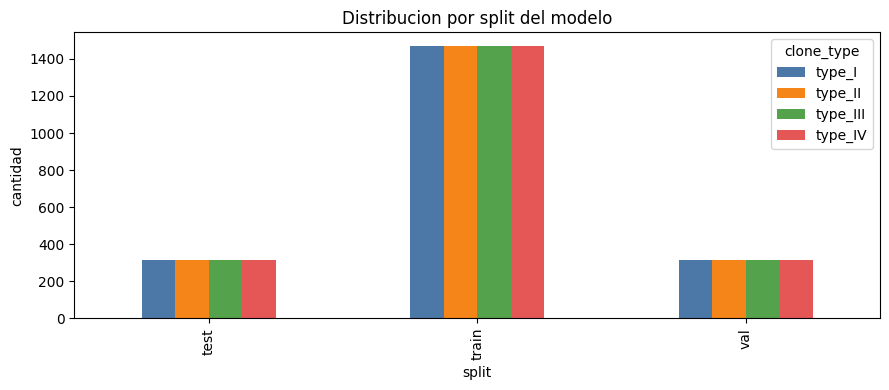

In [8]:
def split_por_grupo(
    # Esta funcion separa train/val/test por problem_id para evitar fuga de informacion.
    df: pd.DataFrame,
    group_col: str,
    target_col: str,
    seed: int = 42,
    train_size: float = 0.7,
    val_size: float = 0.15,
    test_size: float = 0.15,
):
    proporcion_temp = val_size + test_size
    proporcion_test_rel = test_size / proporcion_temp

    gss_train = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=seed)
    idx_train_np, idx_temp_np = next(gss_train.split(df, y=df[target_col], groups=df[group_col]))

    df_temp = df.iloc[idx_temp_np]
    gss_temp = GroupShuffleSplit(n_splits=1, test_size=proporcion_test_rel, random_state=seed)
    idx_val_rel, idx_test_rel = next(gss_temp.split(df_temp, y=df_temp[target_col], groups=df_temp[group_col]))

    idx_train = df.index[idx_train_np]
    idx_val = df_temp.index[idx_val_rel]
    idx_test = df_temp.index[idx_test_rel]
    return idx_train, idx_val, idx_test


def asignar_split(df, idx_train, idx_val, idx_test, nombre_columna='split'):
    # Esta funcion etiqueta cada fila con su split correspondiente.
    datos = df.copy()
    datos[nombre_columna] = 'unassigned'
    datos.loc[idx_train, nombre_columna] = 'train'
    datos.loc[idx_val, nombre_columna] = 'val'
    datos.loc[idx_test, nombre_columna] = 'test'
    return datos


def estadisticas_split(df: pd.DataFrame, split_col: str, target_col: str, group_col: str) -> list[dict[str, Any]]:
    # Esta funcion resume cuantos datos y clases tiene cada split.
    resumen = []
    # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
    for nombre_split, df_split in df.groupby(split_col):
        conteos = df_split[target_col].value_counts().to_dict()
        resumen.append({
            'split': nombre_split,
            'rows': int(len(df_split)),
            'unique_groups': int(df_split[group_col].nunique()),
            'class_distribution': {str(k): int(v) for k, v in conteos.items()},
        })
    return resumen


def balancear_train(df_train: pd.DataFrame, target_col: str, estrategia: str = 'none', seed: int = 42):
    # Esta funcion aplica estrategia de balanceo en entrenamiento cuando se solicita.
    conteos = df_train[target_col].value_counts()
    info = {
        'strategy': estrategia,
        'target_col': target_col,
        'rows_before': int(len(df_train)),
        'class_distribution_before': {str(k): int(v) for k, v in conteos.items()},
    }

    # Si esta condicion se cumple, usamos este camino de logica.
    if estrategia == 'none' or len(conteos) <= 1:
        info['rows_after'] = int(len(df_train))
        info['class_distribution_after'] = info['class_distribution_before']
        return df_train.copy(), info

    # Si esta condicion se cumple, usamos este camino de logica.
    if estrategia == 'undersample':
        n_obj = int(conteos.min())
        rep = False
    # Si la condicion anterior no se cumplio, probamos esta alternativa.
    elif estrategia == 'oversample':
        n_obj = int(conteos.max())
        rep = True
    # Si no se cumplio ningun caso anterior, usamos este caso por defecto.
    else:
        info['rows_after'] = int(len(df_train))
        info['class_distribution_after'] = info['class_distribution_before']
        return df_train.copy(), info

    partes = []
    # Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
    for clase in conteos.index.tolist():
        df_clase = df_train[df_train[target_col] == clase]
        partes.append(df_clase.sample(n=n_obj, replace=rep, random_state=seed))

    out = pd.concat(partes, axis=0).sample(frac=1.0, random_state=seed).copy()
    c2 = out[target_col].value_counts()
    info['rows_after'] = int(len(out))
    info['class_distribution_after'] = {str(k): int(v) for k, v in c2.items()}
    return out, info


idx_train, idx_val, idx_test = split_por_grupo(
    df=datos_preparados,
    group_col='problem_id',
    target_col='clone_type',
    seed=SEED + 100,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
)


datos_modelo = asignar_split(datos_preparados, idx_train, idx_val, idx_test)

print('Estadisticas split del modelo:')
stats_modelo = estadisticas_split(datos_modelo, 'split', 'clone_type', 'problem_id')
# Aqui recorremos elementos uno por uno para procesarlos de forma consistente.
for fila in stats_modelo:
    print(fila)

conteos_split = datos_modelo.groupby(['split', 'clone_type']).size().unstack(fill_value=0)
conteos_split.plot(kind='bar', figsize=(9, 4), color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
plt.title('Distribucion por split del modelo')
plt.xlabel('split')
plt.ylabel('cantidad')
plt.tight_layout()
plt.show()



## 7) Entrenamiento jerarquico por etapas
Esta etapa usa una arquitectura por niveles para cada tipo de clon.
1) Regla deterministica para type_I.
2) Modelo Baker para type_II en los casos restantes.
3) Modelo Baker + AST reducido para separar type_III y type_IV.


In [9]:
# Configuracion del modelo final jerarquico
columna_objetivo_modelo = 'clone_type'
etiquetas_modelo = ['type_I', 'type_II', 'type_III', 'type_IV']
ESTRATEGIA_BALANCEO = 'undersample'
MIN_MATCH_LEN_BAKER = 3
AST_VARIANT_OFICIAL = 'reduced'
MODELO_CLASIFICADOR = 'jerarquico_rf_baker_ast_cf_final'
UMBRAL_TIPO_I = 1.0
UMBRAL_PROB_TIPO_II = 0.5

BAKER_FEATURES_BASE = [
    'baker_match_total_ratio',
    'baker_match_max_ratio',
    'baker_num_blocks',
    'baker_sequence_ratio',
    'baker_edit_distance_norm',
    'baker_token_jaccard',
    'baker_common_token_coverage',
    'baker_len_diff_rel',
]


def evaluar_predicciones(y_true, y_pred, labels: list) -> dict[str, Any]:
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    reporte_dict = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    return {
        'accuracy': float(acc),
        'precision_macro': float(p_macro),
        'recall_macro': float(r_macro),
        'f1_macro': float(f1_macro),
        'confusion_matrix': cm.tolist(),
        'classification_report_dict': reporte_dict,
    }


def es_tipo_i_deterministico(sig_a: str, sig_b: str, umbral: float = 1.0) -> bool:
    if sig_a == sig_b:
        return True
    return SequenceMatcher(None, sig_a, sig_b, autojunk=False).ratio() >= umbral


def detectar_tipo_i_deterministico(df: pd.DataFrame, umbral: float = 1.0) -> pd.Series:
    out = []
    col_a = 'type1_signature_a' if 'type1_signature_a' in df.columns else 'code_a_clean'
    col_b = 'type1_signature_b' if 'type1_signature_b' in df.columns else 'code_b_clean'
    for a, b in zip(df[col_a], df[col_b]):
        out.append(es_tipo_i_deterministico(a, b, umbral=umbral))
    return pd.Series(out, index=df.index, dtype=bool)


def construir_features_tipo_ii(df: pd.DataFrame, min_match_len: int = 3) -> pd.DataFrame:
    fx = construir_features_baker(df, min_match_len=min_match_len)
    return fx[BAKER_FEATURES_BASE].copy()


def construir_features_tipo_iii_iv(df: pd.DataFrame, min_match_len: int = 3, ast_variant: str = 'reduced') -> pd.DataFrame:
    fx_baker = construir_features_baker(df, min_match_len=min_match_len)
    fx_ast = construir_features_ast_par(df)
    if ast_variant == 'reduced':
        fx_ast_sel = seleccionar_ast_reducido(fx_ast)
    else:
        fx_ast_sel = fx_ast

    fx_ast_extra = construir_features_ast_enriquecido_par(df)
    fx_cf = construir_features_control_flow_par(df)
    return pd.concat([fx_baker, fx_ast_sel, fx_ast_extra, fx_cf], axis=1)


def predecir_jerarquico(
    df: pd.DataFrame,
    modelo_tipo_ii: RandomForestClassifier,
    modelo_tipo_iii_iv: RandomForestClassifier,
    min_match_len: int = 3,
    ast_variant: str = 'reduced',
    umbral_tipo_i: float = 1.0,
    umbral_prob_tipo_ii: float = 0.5,
) -> tuple[pd.Series, dict[str, int]]:
    pred = pd.Series(index=df.index, dtype='object')

    mask_i = detectar_tipo_i_deterministico(df, umbral=umbral_tipo_i)
    pred.loc[mask_i] = 'type_I'

    idx_restante = df.index[~mask_i]
    if len(idx_restante) > 0:
        X_t2 = construir_features_tipo_ii(df.loc[idx_restante], min_match_len=min_match_len)
        prob_t2 = modelo_tipo_ii.predict_proba(X_t2)[:, 1]
        pred_t2_bin = (prob_t2 >= umbral_prob_tipo_ii).astype(int)

        idx_type_ii = idx_restante[pred_t2_bin == 1]
        pred.loc[idx_type_ii] = 'type_II'

        idx_restante_2 = pred.index[pred.isna()]
        if len(idx_restante_2) > 0:
            X_t34 = construir_features_tipo_iii_iv(
                df.loc[idx_restante_2],
                min_match_len=min_match_len,
                ast_variant=ast_variant,
            )
            pred.loc[idx_restante_2] = modelo_tipo_iii_iv.predict(X_t34)

    pred = pred.fillna('type_IV')

    resumen = {
        'pred_type_I': int((pred == 'type_I').sum()),
        'pred_type_II': int((pred == 'type_II').sum()),
        'pred_type_III': int((pred == 'type_III').sum()),
        'pred_type_IV': int((pred == 'type_IV').sum()),
    }
    return pred, resumen


def entrenar_evaluar_modelo_jerarquico(
    datos_task,
    columna_target,
    etiquetas,
    seed,
    estrategia_balanceo='none',
    min_match_len=3,
    ast_variant='reduced',
    umbral_tipo_i=1.0,
    umbral_prob_tipo_ii=0.5,
):
    train_raw = datos_task[datos_task['split'] == 'train'].copy()
    val = datos_task[datos_task['split'] == 'val'].copy()
    test = datos_task[datos_task['split'] == 'test'].copy()

    train_balanceado, info_balanceo = balancear_train(train_raw, columna_target, estrategia_balanceo, seed)

    mask_i_train = detectar_tipo_i_deterministico(train_balanceado, umbral=umbral_tipo_i)
    train_etapa2 = train_balanceado.loc[~mask_i_train].copy()

    y_train_t2 = (train_etapa2[columna_target] == 'type_II').astype(int)
    X_train_t2 = construir_features_tipo_ii(train_etapa2, min_match_len=min_match_len)

    modelo_tipo_ii = RandomForestClassifier(
        n_estimators=700,
        max_depth=None,
        min_samples_leaf=1,
        class_weight='balanced_subsample',
        random_state=seed,
        n_jobs=-1,
    )
    modelo_tipo_ii.fit(X_train_t2, y_train_t2)

    train_etapa3 = train_etapa2[train_etapa2[columna_target].isin(['type_III', 'type_IV'])].copy()
    y_train_t34 = train_etapa3[columna_target]
    X_train_t34 = construir_features_tipo_iii_iv(train_etapa3, min_match_len=min_match_len, ast_variant=ast_variant)

    cfg_t34 = {'n_estimators': 800, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
    modelo_tipo_iii_iv = RandomForestClassifier(
        n_estimators=cfg_t34['n_estimators'],
        max_depth=cfg_t34['max_depth'],
        min_samples_leaf=cfg_t34['min_samples_leaf'],
        max_features=cfg_t34['max_features'],
        class_weight='balanced_subsample',
        random_state=1072,
        n_jobs=-1,
    )
    modelo_tipo_iii_iv.fit(X_train_t34, y_train_t34)

    pred_val, resumen_val = predecir_jerarquico(
        val,
        modelo_tipo_ii=modelo_tipo_ii,
        modelo_tipo_iii_iv=modelo_tipo_iii_iv,
        min_match_len=min_match_len,
        ast_variant=ast_variant,
        umbral_tipo_i=umbral_tipo_i,
        umbral_prob_tipo_ii=umbral_prob_tipo_ii,
    )
    pred_test, resumen_test = predecir_jerarquico(
        test,
        modelo_tipo_ii=modelo_tipo_ii,
        modelo_tipo_iii_iv=modelo_tipo_iii_iv,
        min_match_len=min_match_len,
        ast_variant=ast_variant,
        umbral_tipo_i=umbral_tipo_i,
        umbral_prob_tipo_ii=umbral_prob_tipo_ii,
    )

    metricas_val = evaluar_predicciones(val[columna_target], pred_val, labels=etiquetas)
    metricas_test = evaluar_predicciones(test[columna_target], pred_test, labels=etiquetas)

    importancia_t2 = pd.DataFrame({'feature': X_train_t2.columns, 'importance': modelo_tipo_ii.feature_importances_}).sort_values('importance', ascending=False)
    importancia_t34 = pd.DataFrame({'feature': X_train_t34.columns, 'importance': modelo_tipo_iii_iv.feature_importances_}).sort_values('importance', ascending=False)

    return {
        'info_balanceo': info_balanceo,
        'metricas_val': metricas_val,
        'metricas_test': metricas_test,
        'modelo_tipo_ii': modelo_tipo_ii,
        'modelo_tipo_iii_iv': modelo_tipo_iii_iv,
        'num_features_tipo_ii': int(X_train_t2.shape[1]),
        'num_features_t34': int(X_train_t34.shape[1]),
        'feature_importance_tipo_ii': importancia_t2,
        'feature_importance_tipo_iii_iv': importancia_t34,
        'resumen_pred_val': resumen_val,
        'resumen_pred_test': resumen_test,
        'umbral_tipo_i': float(umbral_tipo_i),
        'umbral_prob_tipo_ii': float(umbral_prob_tipo_ii),
        'train_rows_etapa2': int(len(train_etapa2)),
        'train_rows_etapa3': int(len(train_etapa3)),
        'cfg_t34': cfg_t34,
    }


resultado_modelo_actual = entrenar_evaluar_modelo_jerarquico(
    datos_task=datos_modelo,
    columna_target=columna_objetivo_modelo,
    etiquetas=etiquetas_modelo,
    seed=SEED,
    estrategia_balanceo=ESTRATEGIA_BALANCEO,
    min_match_len=MIN_MATCH_LEN_BAKER,
    ast_variant=AST_VARIANT_OFICIAL,
    umbral_tipo_i=UMBRAL_TIPO_I,
    umbral_prob_tipo_ii=UMBRAL_PROB_TIPO_II,
)

print('--- configuracion del modelo final ---')
print('modelo:', MODELO_CLASIFICADOR)
print('ast_variant:', AST_VARIANT_OFICIAL)
print('umbral_tipo_i:', resultado_modelo_actual['umbral_tipo_i'])
print('umbral_prob_tipo_ii:', resultado_modelo_actual['umbral_prob_tipo_ii'])
print('num_features_tipo_ii:', resultado_modelo_actual['num_features_tipo_ii'])
print('num_features_t34:', resultado_modelo_actual['num_features_t34'])
print('cfg_t34:', resultado_modelo_actual['cfg_t34'])

print('\n--- metricas test ---')
for k in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']:
    print(f'{k}: {resultado_modelo_actual["metricas_test"][k]:.4f}')



--- configuracion del modelo final ---
modelo: jerarquico_rf_baker_ast_cf_final
ast_variant: reduced
umbral_tipo_i: 1.0
umbral_prob_tipo_ii: 0.5
num_features_tipo_ii: 8
num_features_t34: 56
cfg_t34: {'n_estimators': 800, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

--- metricas test ---
accuracy: 0.9437
precision_macro: 0.9437
recall_macro: 0.9437
f1_macro: 0.9437


## 8) Evaluacion de la arquitectura jerarquica
Mostramos metricas globales y por clase del sistema por etapas.
Tambien se reportan resultados especificos en `type_III` y `type_IV`.


resumen del modelo final


,modelo,ast_variant,umbral_tipo_i,umbral_prob_tipo_ii,num_features_tipo_ii,num_features_t34,accuracy_val,f1_macro_val,accuracy_test,f1_macro_test
0,jerarquico_rf_baker_ast_cf_final,reduced,1.0,0.5,8,56,0.95,0.949901,0.943651,0.94369


metricas por clase (test)


,label,precision_test,recall_test,f1_test,support_test
0,type_I,1.000000,1.000000,1.000000,315.0
1,type_II,0.996815,0.993651,0.995231,315.0
2,type_III,0.888535,0.885714,0.887122,315.0
3,type_IV,0.889590,0.895238,0.892405,315.0


foco type_III y type_IV


,label,precision_test,recall_test,f1_test,support_test
2,type_III,0.888535,0.885714,0.887122,315.0
3,type_IV,0.889590,0.895238,0.892405,315.0


matriz de confusion del modelo final


,type_I,type_II,type_III,type_IV
type_I,315,0,0,0
type_II,0,313,2,0
type_III,0,1,279,35
type_IV,0,0,33,282


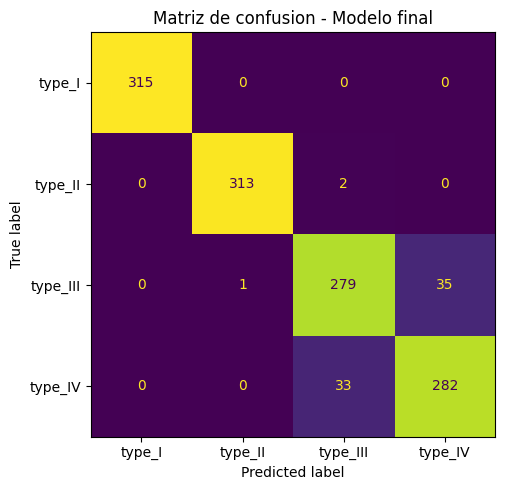

In [10]:
resumen_modelo_final = pd.DataFrame([
    {
        'modelo': MODELO_CLASIFICADOR,
        'ast_variant': AST_VARIANT_OFICIAL,
        'umbral_tipo_i': resultado_modelo_actual['umbral_tipo_i'],
        'umbral_prob_tipo_ii': resultado_modelo_actual['umbral_prob_tipo_ii'],
        'num_features_tipo_ii': resultado_modelo_actual['num_features_tipo_ii'],
        'num_features_t34': resultado_modelo_actual['num_features_t34'],
        'accuracy_val': resultado_modelo_actual['metricas_val']['accuracy'],
        'f1_macro_val': resultado_modelo_actual['metricas_val']['f1_macro'],
        'accuracy_test': resultado_modelo_actual['metricas_test']['accuracy'],
        'f1_macro_test': resultado_modelo_actual['metricas_test']['f1_macro'],
    }
])

print('resumen del modelo final')
display(resumen_modelo_final)

rep = resultado_modelo_actual['metricas_test']['classification_report_dict']
rows_cls = []
for lbl in etiquetas_modelo:
    rows_cls.append({
        'label': lbl,
        'precision_test': rep[lbl]['precision'],
        'recall_test': rep[lbl]['recall'],
        'f1_test': rep[lbl]['f1-score'],
        'support_test': rep[lbl]['support'],
    })

metricas_por_clase = pd.DataFrame(rows_cls).sort_values('label')
print('metricas por clase (test)')
display(metricas_por_clase)

print('foco type_III y type_IV')
display(metricas_por_clase[metricas_por_clase['label'].isin(['type_III', 'type_IV'])])

print('matriz de confusion del modelo final')
cm = np.array(resultado_modelo_actual['metricas_test']['confusion_matrix'])
display(pd.DataFrame(cm, index=etiquetas_modelo, columns=etiquetas_modelo))

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas_modelo).plot(ax=ax, colorbar=False)
ax.set_title('Matriz de confusion - Modelo final')
plt.tight_layout()
plt.show()



## 9) Lectura de resultados
La arquitectura jerarquica permite resolver primero casos simples y despues casos complejos.
Primero filtra `type_I`, luego identifica `type_II` con Baker, y finalmente separa `type_III/type_IV` con Baker+AST.


## 10) Siguiente paso
Con esta base, el ajuste mas util es calibrar umbral de Type I y parametros de los dos modelos RF por etapa.


## 11) Cierre
Esta version final conserva el proyecto actual y lo adapta a una clasificacion jerarquica por niveles de dificultad.
